**ФИО студента**: Дьякова Елизавета Владиславовна

**Группа**: S4102

**Список выполненных пунктов задания**: все задачи

## **Задача 4. Реализация поиска кратчайших путей**

In [ ]:
pip install python-graphblas

In [2]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import graphblas as gb
from graphblas import Matrix, Vector, Scalar
from graphblas import unary, binary, monoid, semiring
import math
import time
from scipy.io import mmread
import os
import random
from scipy.sparse import csr_matrix

Везде считаем, что вершины графа занумерованы подряд с нуля. Обратите внимание на то, что про граф заранее не известно, есть ли в нём циклы отрицательного веса.

Создадим 6 тестовых графов для дальнейшей проверки корректности работы реализаций.

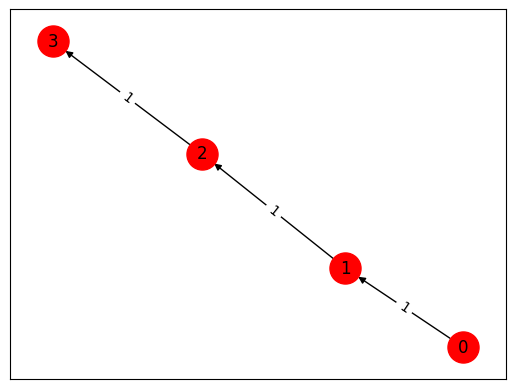

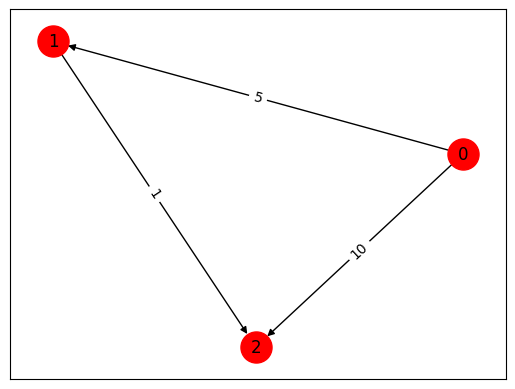

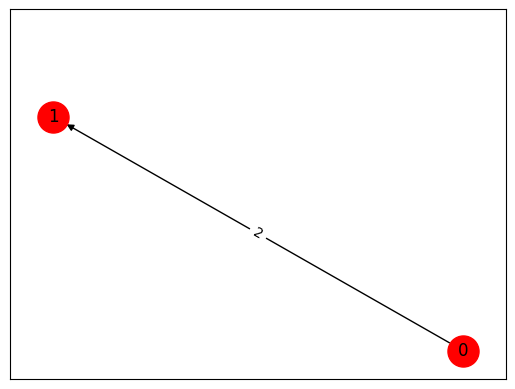

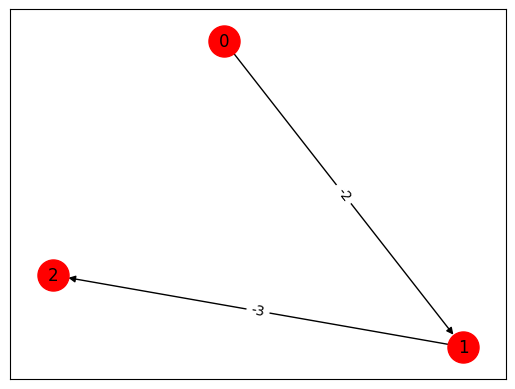

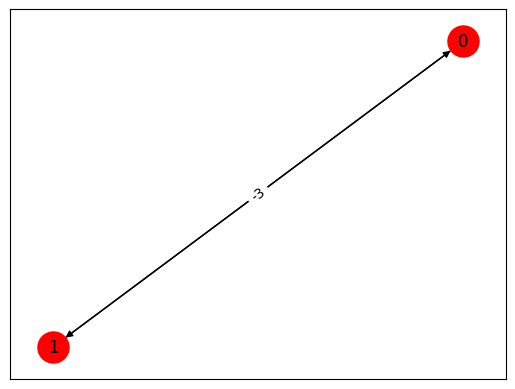

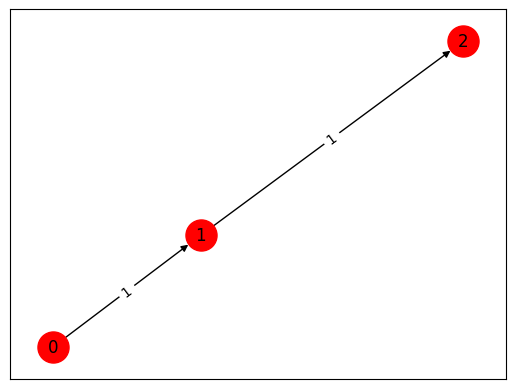

In [3]:
# Линейный граф
M1 = gb.Matrix.from_coo(
    [0, 1, 2],
    [1, 2, 3],
    [1, 1, 1],
    nrows=4, ncols=4)
gb.viz.draw(M1)

# Граф с альтернативными путями
M2 = gb.Matrix.from_coo(
    [0, 0, 1],
    [1, 2, 2],
    [5, 10, 1],
    nrows=3, ncols=3)
gb.viz.draw(M2)

# Несвязный граф
M3 = gb.Matrix.from_coo(
    [0],
    [1],
    [2],
    nrows=3, ncols=3)
gb.viz.draw(M3)

# Граф с отрицательными весами
M4 = gb.Matrix.from_coo(
    [0, 1],
    [1, 2],
    [-2, -3],
    nrows=3, ncols=3)
gb.viz.draw(M4)

# Граф с отрицательным циклом
M5 = gb.Matrix.from_coo(
    [0, 1],
    [1, 0],
    [1, -3],
    nrows=2, ncols=2)
gb.viz.draw(M5)

# Транзитивное замыкание
M6 = gb.Matrix.from_coo(
    [0, 1],
    [1, 2],
    [1, 1],
    nrows=3, ncols=3)
gb.viz.draw(M6)

Используя python-graphblas реализовать функцию поиска кратчайших путей в ориентированном графе из заданной вершины (Bellman–Ford).

*   Функция принимает представление графа, удобное для неё (загрузка, конвертация реализованы отдельно) и номер стартовой вершины.
*   Функция возвращает массив, где для каждой вершины указано расстояние до неё от указанной стартовой вершины. Если вершина не достижима или кратчайшего пути для неё не существует, то значение соответствующей ячейки равно float('inf').


In [4]:
def bellman_ford(m: gb.Matrix, source: int):
    n = m.nrows

    dist = Vector(float, n)
    dist << float('inf')
    dist[source] = 0

    for _ in range(n - 1):
        new_dist = dist.dup()
        new_dist(binary.min) << dist.vxm(m, semiring.min_plus)

        if new_dist.isequal(dist):
            break

        dist = new_dist

    check = dist.dup()
    check(binary.min) << dist.vxm(m, semiring.min_plus)

    bad = Vector(bool, n)

    for i in range(n):
        if check.get(i, float('inf')) < dist.get(i, float('inf')):
            bad[i] = True

    A = m.dup(dtype=bool)
    A << m

    for _ in range(n):
        new_bad = bad.dup()
        new_bad(binary.lor) << bad.vxm(A, semiring.lor_land)

        if new_bad.isequal(bad):
            break

        bad = new_bad

    result = []
    for i in range(n):
        if bad.get(i, False):
            result.append(float('inf'))
        else:
            result.append(dist.get(i, float('inf')))

    return result

Проверим корректность работы на графах

In [5]:
def run_tests():

    print(f'M1')
    result = bellman_ford(M1, 0)
    print(result)
    assert result == [0, 1, 2, 3]

    print(f'M2')
    result = bellman_ford(M2, 0)
    print(result)
    assert result == [0, 5, 6]

    print(f'M3')
    result = bellman_ford(M3, 0)
    print(result)
    assert result == [0, 2, float('inf')]

    print(f'M4')
    result = bellman_ford(M4, 0)
    print(result)
    assert result == [0, -2, -5]

    print(f'M5')
    result = bellman_ford(M5, 0)
    print(result)
    assert result == [float('inf'), float('inf')]

    print(f'M6')
    result = bellman_ford(M6, 0)
    print(result)
    assert result == [0, 1, 2]

    print("Все тесты пройдены")

run_tests()

M1
[0.0, 1.0, 2.0, 3.0]
M2
[0.0, 5.0, 6.0]
M3
[0.0, 2.0, inf]
M4
[0.0, -2.0, -5.0]
M5
[inf, inf]
M6
[0.0, 1.0, 2.0]
Все тесты пройдены


Используя python-graphblas реализовать функцию поиска кратчайших путей в ориентированном графе из нескольких заданных вершин, модифицировав предыдущий алгоритм.

*   Функция принимает представление графа, удобное для неё (загрузка, конвертация реализованы отдельно) и массив номеров стартовых вершин.
*   Функция возвращает массив пар: вершина, и массив, где для каждой вершины указано расстояние до неё из указанной. Если вершина не достижима или кратчайшего пути для неё не существует, то значение соответствующей ячейки равно float('inf').


In [6]:
def bellman_ford_multi(m: gb.Matrix, sources: list[int]):
    n = m.nrows
    k = len(sources)

    dist = Matrix(float, k, n)
    dist(binary.min) << float('inf')

    for i, s in enumerate(sources):
        dist[i, s] << 0.0

    for _ in range(n - 1):
        new_dist = dist.dup()
        new_dist(binary.min) << dist.mxm(m, semiring.min_plus)

        if new_dist.isequal(dist):
            break

        dist = new_dist

    check = dist.dup()
    check(binary.min) << dist.mxm(m, semiring.min_plus)

    bad = Matrix(bool, k, n)

    for i in range(k):
        for j in range(n):
            if check.get(i, j, float('inf')) < dist.get(i, j, float('inf')):
                bad[i, j] << True

    A = m.dup(dtype=bool)
    A(binary.first) << m

    for _ in range(n):
        new_bad = bad.dup()
        new_bad(binary.lor) << bad.mxm(A, semiring.lor_land)

        if new_bad.isequal(bad):
            break

        bad = new_bad

    results = []

    for i in range(k):
        dist_list = []

        for j in range(n):
            if bad.get(i, j, False):
                dist_list.append(float('inf'))
            else:
                val = dist.get(i, j, float('inf'))
                dist_list.append(int(val) if val != float('inf') else float('inf'))

        results.append((sources[i], dist_list))

    return results

Проверим корректность работы

In [9]:
def run_tests():

    print(f'M1')
    result = bellman_ford_multi(M1, [0])
    print(result)
    assert result == [(0, [0, 1, 2, 3])]

    print(f'M2')
    result = bellman_ford_multi(M2, [0])
    print(result)
    assert result == [(0, [0, 5, 6])]

    print(f'M3')
    result = bellman_ford_multi(M3, [0])
    print(result)
    assert result == [(0, [0, 2, float('inf')])]

    print(f'M4')
    result = bellman_ford_multi(M4, [0])
    print(result)
    assert result == [(0, [0, -2, -5])]

    print(f'M5')
    result = bellman_ford_multi(M5, [0])
    print(result)
    assert result == [(0, [float('inf'), float('inf')])]

    print(f'M6')
    result = bellman_ford_multi(M6, [0])
    print(result)
    assert result == [(0, [0, 1, 2])]

    print("Все тесты пройдены")

run_tests()

M1
[(0, [0, 1, 2, 3])]
M2
[(0, [0, 5, 6])]
M3
[(0, [0, 2, inf])]
M4
[(0, [0, -2, -5])]
M5
[(0, [inf, inf])]
M6
[(0, [0, 1, 2])]
Все тесты пройдены


Используя python-graphblas реализовать две функции поиска кратчайших путей в ориентированном графе для всех пар вершин (Floyd–Warshall и вычисление транзитивного замыкания).

*   Функции принимают представление графа, удобное для неё (загрузка, конвертация реализованы отдельно).
*   Функции возвращают массив пар: вершина, и массив, где для каждой вершины указано расстояние до неё из указанной. Если вершина не достижима или кратчайшего пути для неё не существует, то значение соответствующей ячейки равно float('inf').


1. Floyd–Warshall

In [10]:
def floyd_warshall(m: gb.Matrix):
    n = m.nrows

    dist = m.dup(dtype=float)
    dist(binary.min) << float('inf')
    dist(binary.min) << m

    for i in range(n):
        dist[i, i] << 0.0

    for _ in range(n):
        new_dist = dist.dup()
        new_dist(binary.min) << dist.mxm(dist, semiring.min_plus)

        if new_dist.isequal(dist):
            break

        dist = new_dist

    check = dist.dup()
    check(binary.min) << dist.mxm(dist, semiring.min_plus)

    bad = Matrix(bool, n, n)
    for i in range(n):
        for j in range(n):
            if check.get(i, j, float('inf')) < dist.get(i, j, float('inf')):
                bad[i, j] = True

    A = m.dup(dtype=bool)
    A(binary.first) << m

    for _ in range(n):
        new_bad = bad.dup()
        new_bad(binary.lor) << bad.mxm(A, semiring.lor_land)

        if new_bad.isequal(bad):
            break

        bad = new_bad

    results = []
    for i in range(n):
        row = []
        for j in range(n):
            if bad.get(i, j, False):
                row.append(float('inf'))
            else:
                row.append(dist.get(i, j, float('inf')))
        results.append((i, row))

    return results

Проверим корректность работы

In [11]:
def run_tests():

    print('M1')
    result = floyd_warshall(M1)
    print(result)
    assert result[0][1] == [0, 1, 2, 3]

    print('M2')
    result = floyd_warshall(M2)
    print(result)
    assert result[0][1] == [0, 5, 6]

    print('M3')
    result = floyd_warshall(M3)
    print(result)
    assert result[0][1] == [0, 2, float('inf')]

    print('M4')
    result = floyd_warshall(M4)
    print(result)
    assert result[0][1] == [0, -2, -5]

    print('M5')
    result = floyd_warshall(M5)
    print(result)
    assert result == [(0, [float('inf'), float('inf')]), (1, [float('inf'), float('inf')])]

    print('M6')
    result = floyd_warshall(M6)
    print(result)
    assert result[0][1] == [0, 1, 2]

    print("Все тесты пройдены ")

run_tests()

M1
[(0, [0.0, 1.0, 2.0, 3.0]), (1, [inf, 0.0, 1.0, 2.0]), (2, [inf, inf, 0.0, 1.0]), (3, [inf, inf, inf, 0.0])]
M2
[(0, [0.0, 5.0, 6.0]), (1, [inf, 0.0, 1.0]), (2, [inf, inf, 0.0])]
M3
[(0, [0.0, 2.0, inf]), (1, [inf, 0.0, inf]), (2, [inf, inf, 0.0])]
M4
[(0, [0.0, -2.0, -5.0]), (1, [inf, 0.0, -3.0]), (2, [inf, inf, 0.0])]
M5
[(0, [inf, inf]), (1, [inf, inf])]
M6
[(0, [0.0, 1.0, 2.0]), (1, [inf, 0.0, 1.0]), (2, [inf, inf, 0.0])]
Все тесты пройдены 


2. Транзитивное замыкание

In [12]:
def transitive_closure(m: gb.Matrix):
    n = m.nrows

    reach = m.dup(dtype=bool)
    reach(binary.first) << m

    for i in range(n):
        reach[i, i] << True

    for _ in range(n):
        new_reach = reach.dup()

        new_reach(binary.lor) << reach.mxm(reach, semiring.lor_land)

        if new_reach.isequal(reach):
            break

        reach = new_reach

    results = []
    for i in range(n):
        row = []
        for j in range(n):
            row.append(1.0 if reach.get(i, j, False) else float('inf'))
        results.append((i, row))

    return results

Проверим корректность работы

In [13]:
def run_tests_tc():

    print('M1')
    result = transitive_closure(M1)
    print(result)
    assert result[0][1] == [1.0, 1.0, 1.0, 1.0]
    assert result[1][1] == [float('inf'), 1.0, 1.0, 1.0]
    assert result[2][1] == [float('inf'), float('inf'), 1.0, 1.0]
    assert result[3][1] == [float('inf'), float('inf'), float('inf'), 1.0]

    print('M2')
    result = transitive_closure(M2)
    print(result)
    assert result[0][1] == [1.0, 1.0, 1.0]
    assert result[1][1] == [float('inf'), 1.0, 1.0]
    assert result[2][1] == [float('inf'), float('inf'), 1.0]

    print('M3')
    result = transitive_closure(M3)
    print(result)
    assert result[0][1] == [1.0, 1.0, float('inf')]
    assert result[1][1] == [float('inf'), 1.0, float('inf')]
    assert result[2][1] == [float('inf'), float('inf'), 1.0]

    print('M4')
    result = transitive_closure(M4)
    print(result)
    assert result[0][1] == [1.0, 1.0, 1.0]
    assert result[1][1] == [float('inf'), 1.0, 1.0]
    assert result[2][1] == [float('inf'), float('inf'), 1.0]

    print('M5')
    result = transitive_closure(M5)
    print(result)
    for i in range(2):
        for j in range(2):
            assert result[i][1][j] == 1.0

    print('M6')
    result = transitive_closure(M6)
    print(result)
    assert result[0][1] == [1.0, 1.0, 1.0]
    assert result[1][1] == [float('inf'), 1.0, 1.0]
    assert result[2][1] == [float('inf'), float('inf'), 1.0]

    print("Все тесты пройдены")

run_tests_tc()

M1
[(0, [1.0, 1.0, 1.0, 1.0]), (1, [inf, 1.0, 1.0, 1.0]), (2, [inf, inf, 1.0, 1.0]), (3, [inf, inf, inf, 1.0])]
M2
[(0, [1.0, 1.0, 1.0]), (1, [inf, 1.0, 1.0]), (2, [inf, inf, 1.0])]
M3
[(0, [1.0, 1.0, inf]), (1, [inf, 1.0, inf]), (2, [inf, inf, 1.0])]
M4
[(0, [1.0, 1.0, 1.0]), (1, [inf, 1.0, 1.0]), (2, [inf, inf, 1.0])]
M5
[(0, [1.0, 1.0]), (1, [1.0, 1.0])]
M6
[(0, [1.0, 1.0, 1.0]), (1, [inf, 1.0, 1.0]), (2, [inf, inf, 1.0])]
Все тесты пройдены


(+3 балла) Провести экспериментальное исследование полученных реализаций на некоторых больших графах в формате Matrix Market с сайта SuiteSparse Matrix Collection и на случайных сгенерированных. При этом описать зависимость времени работы всех полученных реализаций от размеров графа, его степени разреженности, количестве стартовых вершин. В частности выяснить, начиная с какой доли вершин в графе целесообразнее использовать алгоритм поиска кратчайших путей для всех пар вершин вместо того, чтобы решать задачу поиска кратчайших путей из нескольких стартовых (модифицированный Bellman-Ford).

In [ ]:
!gdown 1BvM_4yZxBQcQPPTVNTGQ3HTyM3fg-d0x
!unzip data_graph.zip
!rm -rf data_graph.zip

In [6]:
def measure_time(func, A, sources=None):
    start = time.perf_counter()
    if sources is None:
        func(A)
    else:
        func(A, sources)
    end = time.perf_counter()
    return end - start

In [ ]:
results = []

paths = [
    './epb3/epb3/epb3.mtx',
    './pkustk12/pkustk12/pkustk12.mtx',
    './twotone/twotone/twotone.mtx',
    './hcircuit/hcircuit/hcircuit.mtx',
    './g7jac160/g7jac160/g7jac160.mtx',
    './bcsstk32/bcsstk32/bcsstk32.mtx',
    './bcircuit/bcircuit/bcircuit.mtx',
    './onera_dual/onera_dual/onera_dual.mtx',
    './circuit_4/circuit_4/circuit_4.mtx',
    './ct20stif/ct20stif/ct20stif.mtx']

for path in paths:
    name = os.path.basename(path)

    M = mmread(path)

    rows, cols = M.tocsr().nonzero()

    A = Matrix.from_coo(rows, cols, [True] * len(rows), nrows=M.shape[0], ncols=M.shape[1])

    n = A.nrows

    source = 0
    sources = [source]

    t_bellman = measure_time(bellman_ford, A, sources)
    t_bellman_multi = measure_time(bellman_ford_multi, A, sources)

    density = A.nvals / (n * n)

    results.append((name, n, A.nvals, density, t_bellman, t_bellman_multi))

    print(
        f"{name}: "
        f"n={n}, edges={A.nvals}, density={density:.6f}, "
        f"bellman={t_bellman:.4f}, "
        f"bellman_multi={t_bellman_multi:.4f}")

df = pd.DataFrame(results, columns=[
    "graph", "n", "edges", "density",
    "bellman", "bellman_multi"])
print(df)

epb3.mtx: n=84617, edges=463625, density=0.000065, bellman=14.1091, bellman_multi=17.4569
pkustk12.mtx: n=94653, edges=7512317, density=0.000839, bellman=13.2180, bellman_multi=19.1563
twotone.mtx: n=120750, edges=1206265, density=0.000083, bellman=14.0274, bellman_multi=19.7847
hcircuit.mtx: n=105676, edges=513072, density=0.000046, bellman=15.0316, bellman_multi=16.6544
g7jac160.mtx: n=47430, edges=564952, density=0.000251, bellman=6.0557, bellman_multi=6.8231
bcsstk32.mtx: n=44609, edges=2014701, density=0.001012, bellman=7.7635, bellman_multi=7.8279
bcircuit.mtx: n=68902, edges=375558, density=0.000079, bellman=9.7879, bellman_multi=11.2859
onera_dual.mtx: n=85567, edges=419201, density=0.000057, bellman=10.7858, bellman_multi=14.3522
circuit_4.mtx: n=80209, edges=307604, density=0.000048, bellman=9.3669, bellman_multi=11.8674
ct20stif.mtx: n=52329, edges=2600295, density=0.000950, bellman=6.7581, bellman_multi=9.4686
            graph       n    edges   density    bellman  bellman

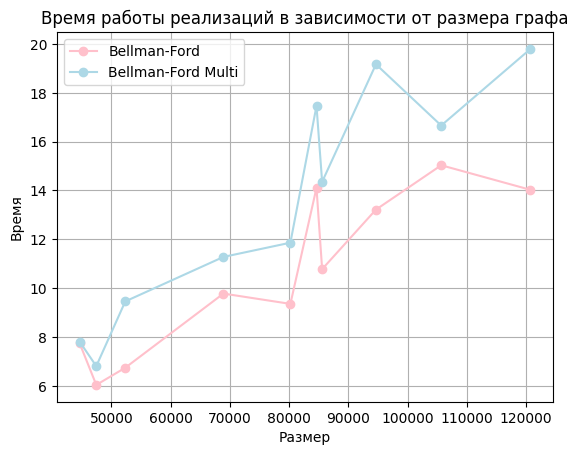

In [ ]:
df_sorted = df.sort_values(by="n")

plt.figure()

plt.plot(df_sorted["n"], df_sorted["bellman"], marker='o', label="Bellman-Ford", color = 'pink')
plt.plot(df_sorted["n"], df_sorted["bellman_multi"], marker='o', label="Bellman-Ford Multi", color = 'lightblue')

plt.xlabel("Размер")
plt.ylabel("Время")
plt.title("Время работы реализаций в зависимости от размера графа")

plt.legend()
plt.grid()

plt.show()

In [ ]:
path = './epb3/epb3/epb3.mtx'

M = mmread(path)

rows, cols = M.tocsr().nonzero()

A = Matrix.from_coo(rows, cols, [True] * len(rows), nrows=M.shape[0], ncols=M.shape[1])

sources_list = [[0], list(range(3)), list(range(5)), list(range(7)), list(range(10))]
results_k = []

for sources in sources_list:
    k = len(sources)

    # Bellman-Ford
    start = time.perf_counter()
    for s in sources:
        bellman_ford(A, s)
    t_bellman_total = time.perf_counter() - start

    # Bellman-Ford Multi
    t_multi = measure_time(bellman_ford_multi, A, sources)

    results_k.append((k, t_bellman_total, t_multi))

    print(f"k={k}: bellman_total={t_bellman_total:.4f}, multi={t_multi:.4f}")

k=1: bellman_total=14.5165, multi=17.8635
k=3: bellman_total=41.6757, multi=37.0838
k=5: bellman_total=68.8782, multi=54.6886
k=7: bellman_total=97.1765, multi=70.8715
k=10: bellman_total=139.0495, multi=99.4872


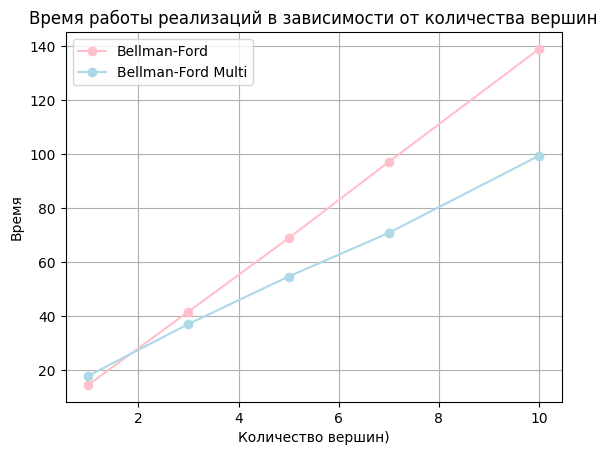

In [ ]:
df_k = pd.DataFrame(results_k, columns=["k", "bellman_total", "multi"])

plt.figure()

plt.plot(df_k["k"], df_k["bellman_total"], marker='o', label="Bellman-Ford", color = 'pink')
plt.plot(df_k["k"], df_k["multi"], marker='o', label="Bellman-Ford Multi", color = 'lightblue')
plt.xlabel("Количество вершин)")
plt.ylabel("Время")
plt.title("Время работы реализаций в зависимости от количества вершин")
plt.legend()
plt.grid()

plt.show()

In [7]:
def generate_random_graph(n, sparsity, weighted=True, weight_range=(1, 10)):
    rows, cols, vals = [], [], []

    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < sparsity:
                if weighted:
                    w = random.uniform(*weight_range)
                else:
                    w = True

                rows += [i, j]
                cols += [j, i]
                vals += [w, w]

    return Matrix.from_coo(rows, cols, vals, nrows=n, ncols=n)

In [ ]:
# Зависимость от размера графа
sizes = [300, 600, 1000]
sparsity = 0.01
k = 5

results_size = []

for n in sizes:
    A = generate_random_graph(n, sparsity)
    sources = list(range(k))

    t_bellman = sum(measure_time(bellman_ford, A, [s]) for s in sources)
    t_multi = measure_time(bellman_ford_multi, A, sources)
    t_floyd = measure_time(floyd_warshall, A)
    t_trans = measure_time(transitive_closure, A)

    density = A.nvals / (n * n)

    results_size.append((n, density, t_bellman, t_multi, t_floyd, t_trans))

    print(f"n={n}: bellman={t_bellman:.4f}, bellman_multi={t_multi:.4f}, "
          f"floyd={t_floyd:.4f}, transitive_closure={t_trans:.4f}")

n=300: bellman=0.2120, bellman_multi=0.1531, floyd=5.3403, transitive_closure=3.9749
n=600: bellman=0.3216, bellman_multi=0.2548, floyd=26.5839, transitive_closure=14.9388
n=1000: bellman=0.5914, bellman_multi=0.4323, floyd=88.8082, transitive_closure=42.5235


In [ ]:
# Зависимость от разреженности
n = 1000
k = 5
sparsities = [0.001, 0.01, 0.05, 0.1]

results_sparse = []

for sparsity in sparsities:
    A = generate_random_graph(n, sparsity)
    sources = list(range(k))

    t_bellman = sum(measure_time(bellman_ford, A, [s]) for s in sources)
    t_multi = measure_time(bellman_ford_multi, A, sources)
    t_floyd = measure_time(floyd_warshall, A)
    t_trans = measure_time(transitive_closure, A)

    density = A.nvals / (n * n)

    results_sparse.append((sparsity, density, t_bellman, t_multi, t_floyd, t_trans))

    print(f"sparsity={sparsity}: density={density:.6f}, bellman={t_bellman:.4f}, bellman_multi={t_multi:.4f}, "
          f"floyd={t_floyd:.4f}, transitive_closure={t_trans:.4f}")

sparsity=0.001: density=0.001000, bellman=0.5841, bellman_multi=0.4217, floyd=93.3849, transitive_closure=31.9428
sparsity=0.01: density=0.009748, bellman=0.5635, bellman_multi=0.3892, floyd=82.7305, transitive_closure=41.1743
sparsity=0.05: density=0.050556, bellman=0.5339, bellman_multi=0.4148, floyd=66.8188, transitive_closure=39.9364
sparsity=0.1: density=0.100120, bellman=0.5631, bellman_multi=0.4187, floyd=63.4548, transitive_closure=39.3959


In [9]:
# Зависимость от числа стартовых вершин
n = 1000
sparsity = 0.01
A = generate_random_graph(n, sparsity)
k_values = [1, 3, 5, 7, 10]

t_floyd = measure_time(floyd_warshall, A)
t_trans = measure_time(transitive_closure, A)

results_k = []

for k in k_values:
    sources = list(range(k))

    t_bellman = sum(measure_time(bellman_ford, A, [s]) for s in sources)
    t_multi = measure_time(bellman_ford_multi, A, sources)

    results_k.append((k, t_bellman, t_multi, t_floyd, t_trans))

    print(f"k={k}: bellman={t_bellman:.4f}, bellman_multi={t_multi:.4f}, "
          f"floyd={t_floyd:.4f}, transitive_closure={t_trans:.4f}")

k=1: bellman=0.1725, bellman_multi=0.2089, floyd=84.8317, transitive_closure=56.2494
k=3: bellman=0.3113, bellman_multi=0.2462, floyd=84.8317, transitive_closure=56.2494
k=5: bellman=0.5315, bellman_multi=0.4183, floyd=84.8317, transitive_closure=56.2494
k=7: bellman=0.7542, bellman_multi=0.5219, floyd=84.8317, transitive_closure=56.2494
k=10: bellman=1.0364, bellman_multi=0.7096, floyd=84.8317, transitive_closure=56.2494


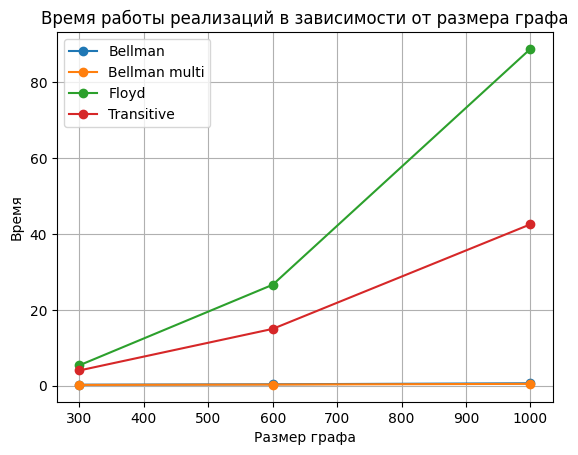

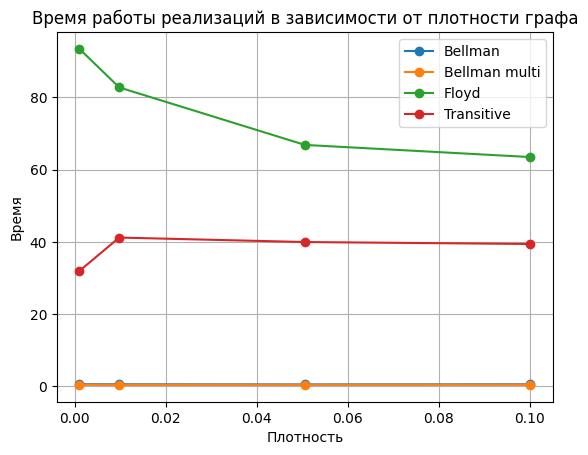

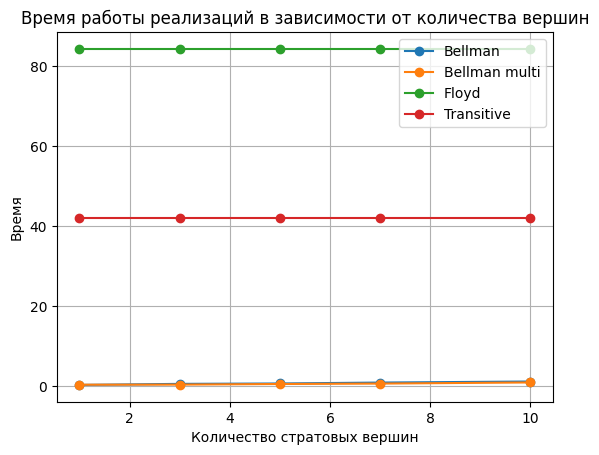

In [ ]:
df_size = pd.DataFrame(results_size, columns=["n", "density", "bellman", "multi", "floyd", "trans"])

plt.figure()
plt.plot(df_size["n"], df_size["bellman"], marker='o', label="Bellman")
plt.plot(df_size["n"], df_size["multi"], marker='o', label="Bellman multi")
plt.plot(df_size["n"], df_size["floyd"], marker='o', label="Floyd")
plt.plot(df_size["n"], df_size["trans"], marker='o', label="Transitive")

plt.xlabel("Размер графа")
plt.ylabel("Время")
plt.title("Время работы реализаций в зависимости от размера графа")

plt.legend()
plt.grid()


df_sparse = pd.DataFrame(results_sparse, columns=["sparsity", "density", "bellman", "multi", "floyd", "trans"])

plt.figure()
plt.plot(df_sparse["density"], df_sparse["bellman"], marker='o', label="Bellman")
plt.plot(df_sparse["density"], df_sparse["multi"], marker='o', label="Bellman multi")
plt.plot(df_sparse["density"], df_sparse["floyd"], marker='o', label="Floyd")
plt.plot(df_sparse["density"], df_sparse["trans"], marker='o', label="Transitive")

plt.xlabel("Плотность")
plt.ylabel("Время")
plt.title("Время работы реализаций в зависимости от плотности графа")

plt.legend()
plt.grid()


df_k = pd.DataFrame(results_k, columns=["k", "bellman", "multi", "floyd", "trans"])

plt.figure()
plt.plot(df_k["k"], df_k["bellman"], marker='o', label="Bellman")
plt.plot(df_k["k"], df_k["multi"], marker='o', label="Bellman multi")
plt.plot(df_k["k"], df_k["floyd"], marker='o', label="Floyd")
plt.plot(df_k["k"], df_k["trans"], marker='o', label="Transitive")

plt.xlabel("Количество стратовых вершин")
plt.ylabel("Время")
plt.title("Время работы реализаций в зависимости от количества стартовых вершин")

plt.legend()
plt.grid()

plt.show()

**Вывод:**

На больших графах с SuiteSparse Matrix Collection было проведено сравнение реализаций Bellman–Ford и Bellman–Ford Multi. Bellman–Ford  показывает лучшее время по сравнению с Bellman–Ford Multi реализацией (при k = 1), что связано с дополнительными накладными расходами матричных операций при одной стартовой вершине. Также можно отметить, что размер графа влияет на время работы алгоритмов, но время также зависит и от структуры графа: на разреженных графах Bellman–Ford, как правило, быстрее, но с увеличением плотности разница во времени между алгоритмами сокращается (при k = 1).

Также было проанализировано время работы алгоритмов в зависимости от числа стартовых вершин на примере одного из графов. Полученные результаты демонстрируют увеличение времени работы с увеличением числа стартовых вершин. При этом, Bellman–Ford Multi оказывается быстрее, так как все источники обрабатываются одновременно, в отличие от Bellman–Ford, где алгоритм запускается для каждой вершины отдельно.

На сгенерированных графах были проведены сравнения всех реализаций. Результаты согласуются с экспериментами на больших графах.
Так, можно отметить, что при увеличении размера графа время работы всех алгоритмов возрастает, при этом Bellman–Ford и Bellman–Ford Multi масштабируются значительно лучше, чем Floyd–Warshall и алгоритм транзитивного замыкания, для которых наблюдается существенно более быстрый рост времени, что объясняется их кубической сложностью. Анализируя влияние разреженности, можно отметить, что с увеличением плотности графа время работы Floyd–Warshall и  транзитивного замыкания наблюдается тенденция к уменьшению времени, тогда как Bellman–Ford и Bellman–Ford Multi меняются незначительно. При увеличении числа стартовых вершин наблюдается линейный рост времени Bellman–Ford, тогда как Bellman–Ford Multi масштабируется значительно лучше и становится быстрее уже при k > 3. При этом время работы Floyd–Warshall и транзитивного замыкания не зависит от числа стартовых вершин.

Проведем эксперименты и попробуем понять, начиная с какой доли вершин в графе целесообразнее использовать алгоритм поиска кратчайших путей для всех пар вершин вместо того, чтобы решать задачу поиска кратчайших путей из нескольких стартовых (модифицированный Bellman-Ford).

In [11]:
n = 500
sparsity = 0.01
A = generate_random_graph(n, sparsity)

k_values = [int(n * frac) for frac in [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0]]

t_floyd = measure_time(floyd_warshall, A)
print(f"Floyd готов: {t_floyd:.2f}s")

results = []
for k in k_values:
    sources = list(range(k))
    t_multi = measure_time(bellman_ford_multi, A, sources)
    frac = k / n
    results.append((frac, t_multi, t_floyd))
    print(f"k={k} ({frac:.0%}): bellman_multi={t_multi:.2f}s, floyd={t_floyd:.2f}s")

Floyd готов: 15.23s
k=5 (1%): bellman_multi=0.22s, floyd=15.23s
k=25 (5%): bellman_multi=0.84s, floyd=15.23s
k=50 (10%): bellman_multi=1.70s, floyd=15.23s
k=100 (20%): bellman_multi=3.38s, floyd=15.23s
k=150 (30%): bellman_multi=6.07s, floyd=15.23s
k=250 (50%): bellman_multi=8.95s, floyd=15.23s
k=350 (70%): bellman_multi=12.64s, floyd=15.23s
k=450 (90%): bellman_multi=17.05s, floyd=15.23s
k=500 (100%): bellman_multi=17.44s, floyd=15.23s


In [10]:
n = 500
sparsity = 0.3
A = generate_random_graph(n, sparsity)

k_values = [int(n * frac) for frac in [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0]]

t_floyd = measure_time(floyd_warshall, A)
print(f"Floyd готов: {t_floyd:.2f}s")

results = []
for k in k_values:
    sources = list(range(k))
    t_multi = measure_time(bellman_ford_multi, A, sources)
    frac = k / n
    results.append((frac, t_multi, t_floyd))
    print(f"k={k} ({frac:.0%}): bellman_multi={t_multi:.2f}s, floyd={t_floyd:.2f}s")

Floyd готов: 11.65s
k=5 (1%): bellman_multi=0.22s, floyd=11.65s
k=25 (5%): bellman_multi=0.89s, floyd=11.65s
k=50 (10%): bellman_multi=1.77s, floyd=11.65s
k=100 (20%): bellman_multi=4.13s, floyd=11.65s
k=150 (30%): bellman_multi=5.85s, floyd=11.65s
k=250 (50%): bellman_multi=9.91s, floyd=11.65s
k=350 (70%): bellman_multi=13.17s, floyd=11.65s
k=450 (90%): bellman_multi=16.54s, floyd=11.65s
k=500 (100%): bellman_multi=18.61s, floyd=11.65s


**Вывод:** На графах размера n = 500 с различной плотностью и варьировании числа стартовых вершин, было выявлено, что при малых значениях k алгоритм Bellman–Ford Multi значительно превосходит Floyd–Warshall. Однако с увеличением числа стартовых вершин время работы Bellman–Ford Multi возрастает линейно, и при больших значениях k его преимущество сокращается. При плотности 0.01 пересечение наступает примерно при k ≈ 80% вершин, тогда как при плотности 0.3 — уже при k ≈ 60%. Это указывает на существование порогового значения числа источников, при котором выбор между алгоритмами должен учитывать не только размер графа, но и количество обрабатываемых стартовых вершин.

(+2 балла) Оценить эффект от использования push/pull direction optimization для векторно-матричных операциях в алгоритмах. Попробовать разные стратегии (всегда push, всегда pull, использовать порог наполненности вектора и т.д.).

In [38]:
def measure_time_p(func, *args):
    start = time.time()
    result = func(*args)
    return time.time() - start, result

In [52]:
def generate_graph(n, sparsity, weight_scale=10):
    A = np.random.rand(n, n)
    A[A > sparsity] = 0
    A = A * weight_scale
    return gb.Matrix.from_dense(A)

In [53]:
def bellman_push(m: gb.Matrix, sources: list):
    n = m.shape[0]
    dist = Vector(float, n)
    for s in sources:
        dist[s] = 0.0

    for _ in range(n - 1):
        new_dist = dist.dup()
        new_dist(binary.min) << dist.vxm(m, semiring.min_plus)
        if new_dist.isequal(dist):
            break
        dist = new_dist

    return dist.to_dense(fill_value=float('inf'))


def bellman_pull(m: gb.Matrix, sources: list):
    n = m.shape[0]
    dist = Vector(float, n)
    for s in sources:
        dist[s] = 0.0

    AT = m.T

    for _ in range(n - 1):
        new_dist = dist.dup()
        new_dist(binary.min) << AT.mxv(dist, semiring.min_plus)
        if new_dist.isequal(dist):
            break
        dist = new_dist

    return dist.to_dense(fill_value=float('inf'))


def bellman_hybrid(m: gb.Matrix, sources: list, threshold=0.1):
    n = m.shape[0]
    dist = Vector(float, n)
    for s in sources:
        dist[s] = 0.0

    AT = m.T

    for _ in range(n - 1):
        new_dist = dist.dup()

        ratio = dist.nvals / n

        if ratio < threshold:
            new_dist(binary.min) << dist.vxm(m, semiring.min_plus)
        else:
            new_dist(binary.min) << AT.mxv(dist, semiring.min_plus)

        if new_dist.isequal(dist):
            break
        dist = new_dist

    return dist.to_dense(fill_value=float('inf'))

In [58]:
def experiment_by_size():

    sizes = [200, 400, 600, 800]
    sparsity = 0.02

    for n in sizes:
        print(f"\nn={n}")

        A = generate_graph(n, sparsity)
        sources = [0]

        t, _ = measure_time_p(bellman_push, A, sources)
        print(f"Push: {t:.4f}s")

        t, _ = measure_time_p(bellman_pull, A, sources)
        print(f"Pull: {t:.4f}s")

        t, _ = measure_time_p(bellman_hybrid, A, sources)
        print(f"Hybrid: {t:.4f}s")

experiment_by_size()


n=200
Push: 0.0020s
Pull: 0.0019s
Hybrid: 0.0015s

n=400
Push: 0.0026s
Pull: 0.0024s
Hybrid: 0.0024s

n=600
Push: 0.0052s
Pull: 0.0050s
Hybrid: 0.0045s

n=800
Push: 0.0079s
Pull: 0.0082s
Hybrid: 0.0080s


In [60]:
def experiment_by_density():
    n = 400
    densities = [0.005, 0.01, 0.05, 0.1, 0.2]

    for sparsity in densities:
        print(f"\nsparsity={sparsity}")
        A = generate_graph(n, sparsity)
        sources = [0]

        t, _ = measure_time_p(bellman_push, A, sources)
        print(f"Push: {t:.4f}s")

        t, _ = measure_time_p(bellman_pull, A, sources)
        print(f"Pull: {t:.4f}s")

        t, _ = measure_time_p(bellman_hybrid, A, sources)
        print(f"Hybrid: {t:.4f}s")

experiment_by_density()


sparsity=0.005
Push: 0.0031s
Pull: 0.0025s
Hybrid: 0.0028s

sparsity=0.01
Push: 0.0025s
Pull: 0.0022s
Hybrid: 0.0021s

sparsity=0.05
Push: 0.0023s
Pull: 0.0021s
Hybrid: 0.0022s

sparsity=0.1
Push: 0.0027s
Pull: 0.0023s
Hybrid: 0.0023s

sparsity=0.2
Push: 0.0024s
Pull: 0.0021s
Hybrid: 0.0022s


In [61]:
def experiment_by_sources():
    n = 400
    sparsity = 0.02

    A = generate_graph(n, sparsity)

    k_values = [1, 5, 10, 20, 50, 100]

    for k in k_values:
        sources = list(range(k))
        print(f"\nk={k}")

        t, _ = measure_time_p(bellman_push, A, sources)
        print(f"Push: {t:.4f}s")

        t, _ = measure_time_p(bellman_pull, A, sources)
        print(f"Pull: {t:.4f}s")

        t, _ = measure_time_p(bellman_hybrid, A, sources)
        print(f"Hybrid: {t:.4f}s")

experiment_by_sources()


k=1
Push: 0.0035s
Pull: 0.0021s
Hybrid: 0.0021s

k=5
Push: 0.0013s
Pull: 0.0012s
Hybrid: 0.0012s

k=10
Push: 0.0013s
Pull: 0.0013s
Hybrid: 0.0013s

k=20
Push: 0.0025s
Pull: 0.0015s
Hybrid: 0.0016s

k=50
Push: 0.0021s
Pull: 0.0022s
Hybrid: 0.0022s

k=100
Push: 0.0032s
Pull: 0.0032s
Hybrid: 0.0033s


**Вывод:** Опираясь на полученные результаты можно сделать вывод, что время работы алгороитмов растет с увеличением размера графа, но при этом различия остаются незначительными. Hybrid незначительно выигрывает на малых графах, но с увеличением размера результаты стратегий сопоставимы.

При изменении плотности графа все стратегии показывают достаточно стабильные и примерно одинковые результаты.

Оценивая влияние числа стартовых вершин, можно отметить, что при k=1, Push показывает более длительное время работы, однако с увеличением числа стартовых вершин, результаты становятся соспоставимыми.

Так, на графах небольшого размера эффект от использования push/pull direction optimization минимален, преимущество стратегий ожидается на более больших графах.